# Step 6: Exploration & Visualization

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Explore and visualize the corpus using statistical and visualization methods.
Includes at least 3 advanced visualization types: hierarchical clustering, heatmaps, scatter plots, KDE plots, t-SNE plots.

# Set Up

In [30]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
%matplotlib inline

In [32]:
output_dir = 'output'

OHCO = ['book_id', 'chapter', 'para_num', 'sent_num']
emo_cols = 'anger anticipation disgust fear joy sadness surprise trust'.split()

# Load Data

In [33]:
TOKEN = pd.read_csv(os.path.join(output_dir, 'TOKEN.csv'))
VOCAB = pd.read_csv(os.path.join(output_dir, 'VOCAB.csv'), index_col='term_str')
LIBRARY = pd.read_csv(os.path.join(output_dir, 'LIBRARY.csv'), index_col='book_id')
TFIDF = pd.read_csv(os.path.join(output_dir, 'TFIDF.csv'), index_col='book_id')
DOC_COMPONENTS = pd.read_csv(os.path.join(output_dir, 'DOC_COMPONENTS.csv'), index_col='book_id')
DOC_TOPICS = pd.read_csv(os.path.join(output_dir, 'DOC_TOPICS.csv'), index_col='book_id')
DOC_SENTIMENT = pd.read_csv(os.path.join(output_dir, 'DOC_SENTIMENT.csv'), index_col='book_id')
WORD2VEC = pd.read_csv(os.path.join(output_dir, 'WORD2VEC.csv'), index_col='term_str')
TOPIC_TERMS = pd.read_csv(os.path.join(output_dir, 'TOPIC_TERMS.csv'), index_col=0)

In [34]:
# Map book_id to title for labeling
id_to_title = LIBRARY['title'].to_dict()
id_to_genre = LIBRARY['genre'].to_dict()

# 1. Hierarchical Cluster Dendrogram

Cluster the 12 novels based on their TFIDF profiles.

In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

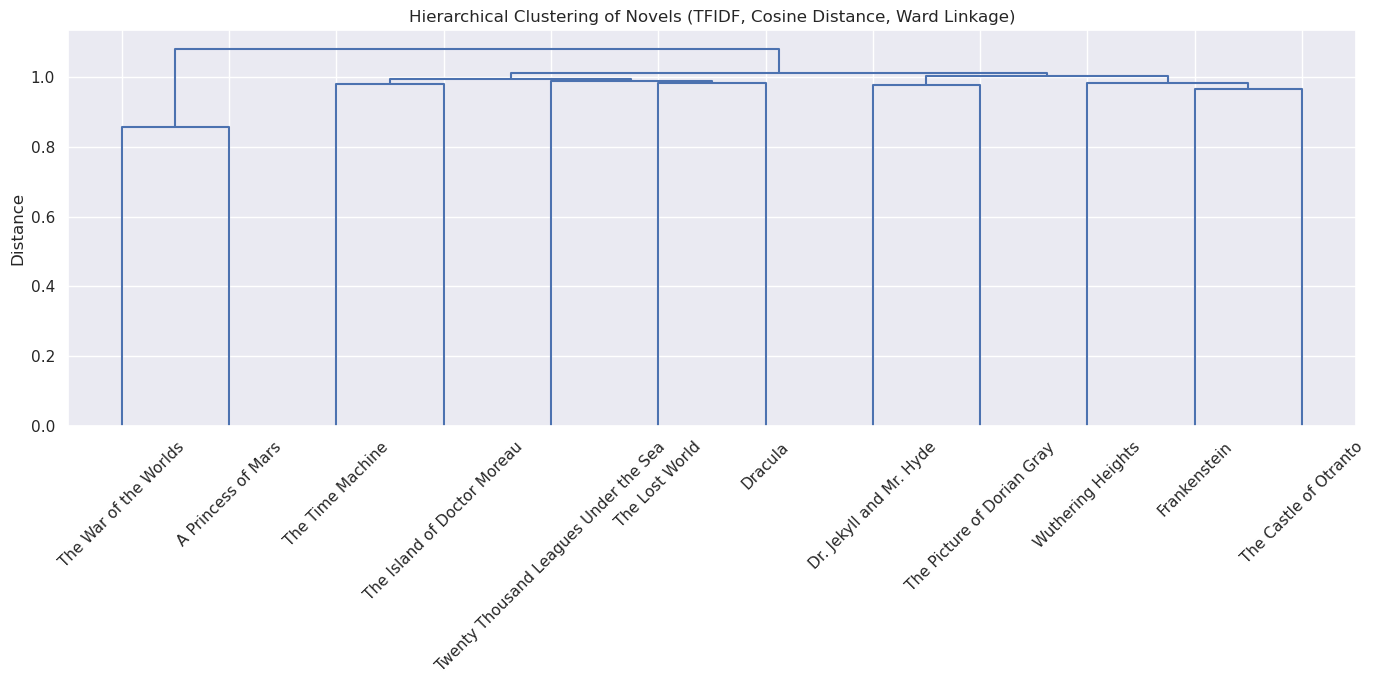

In [36]:
# Use cosine distance on TFIDF
dist = pdist(TFIDF.values, metric='cosine')
Z = linkage(dist, method='ward')

labels = [id_to_title[i] for i in TFIDF.index]

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, labels=labels, leaf_rotation=45, leaf_font_size=11, ax=ax)
ax.set_title('Hierarchical Clustering of Novels (TFIDF, Cosine Distance, Ward Linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# 2. Heatmap: Emotion Correlations Across Books

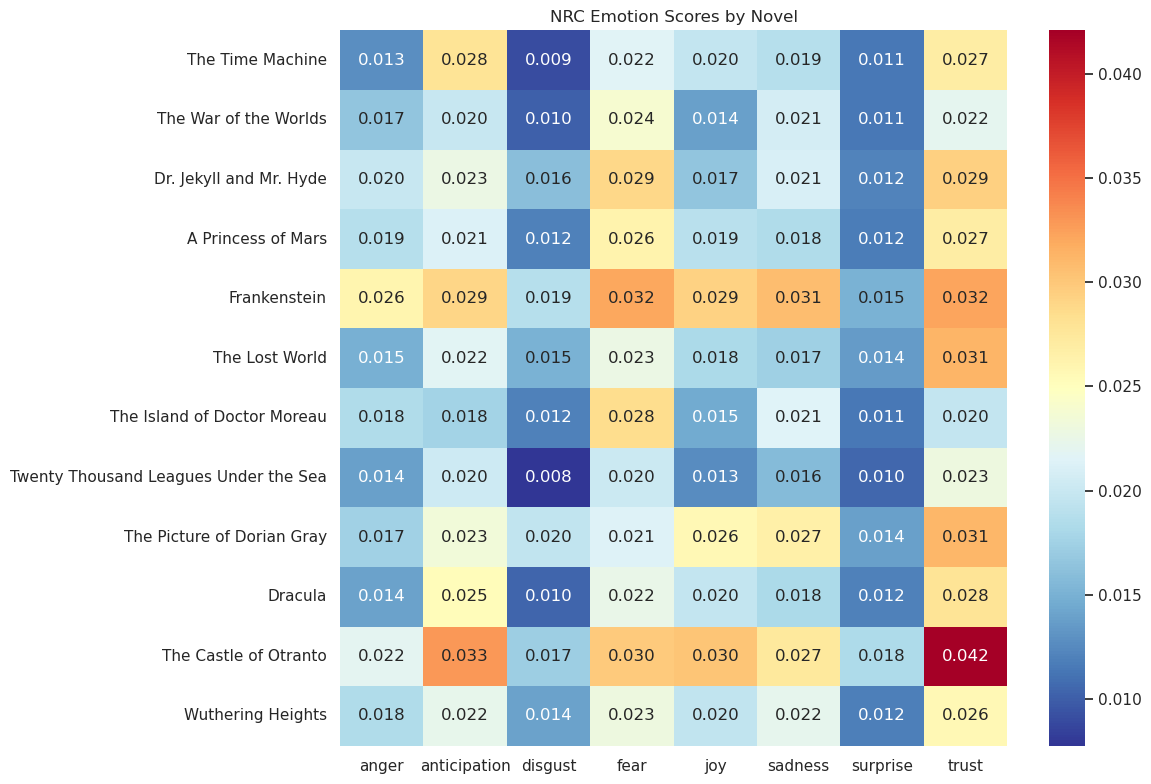

In [37]:
# Average emotion per book
book_emo = TOKEN.groupby('book_id')[emo_cols].mean()
book_emo.index = [id_to_title[i] for i in book_emo.index]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(book_emo, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax)
ax.set_title('NRC Emotion Scores by Novel')
plt.tight_layout()
plt.show()

# 3. Heatmap: Correlation Between Emotions

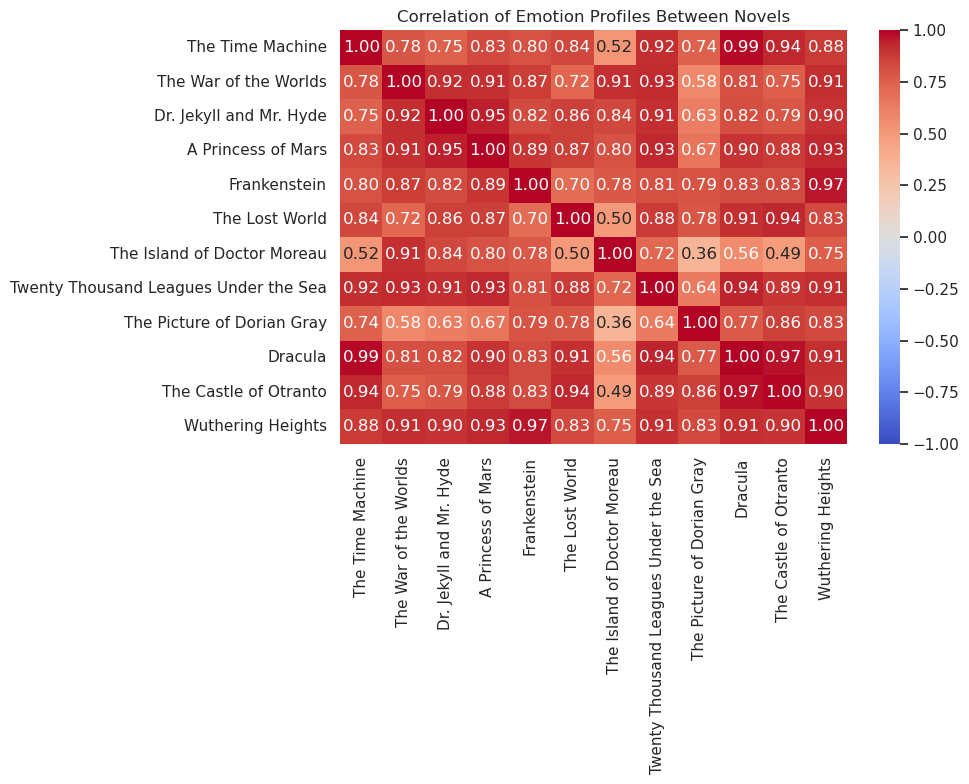

In [38]:
emo_corr = book_emo.T.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(emo_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation of Emotion Profiles Between Novels')
plt.tight_layout()
plt.show()

# 4. PCA Scatter Plot: PC0 vs PC1 by Genre

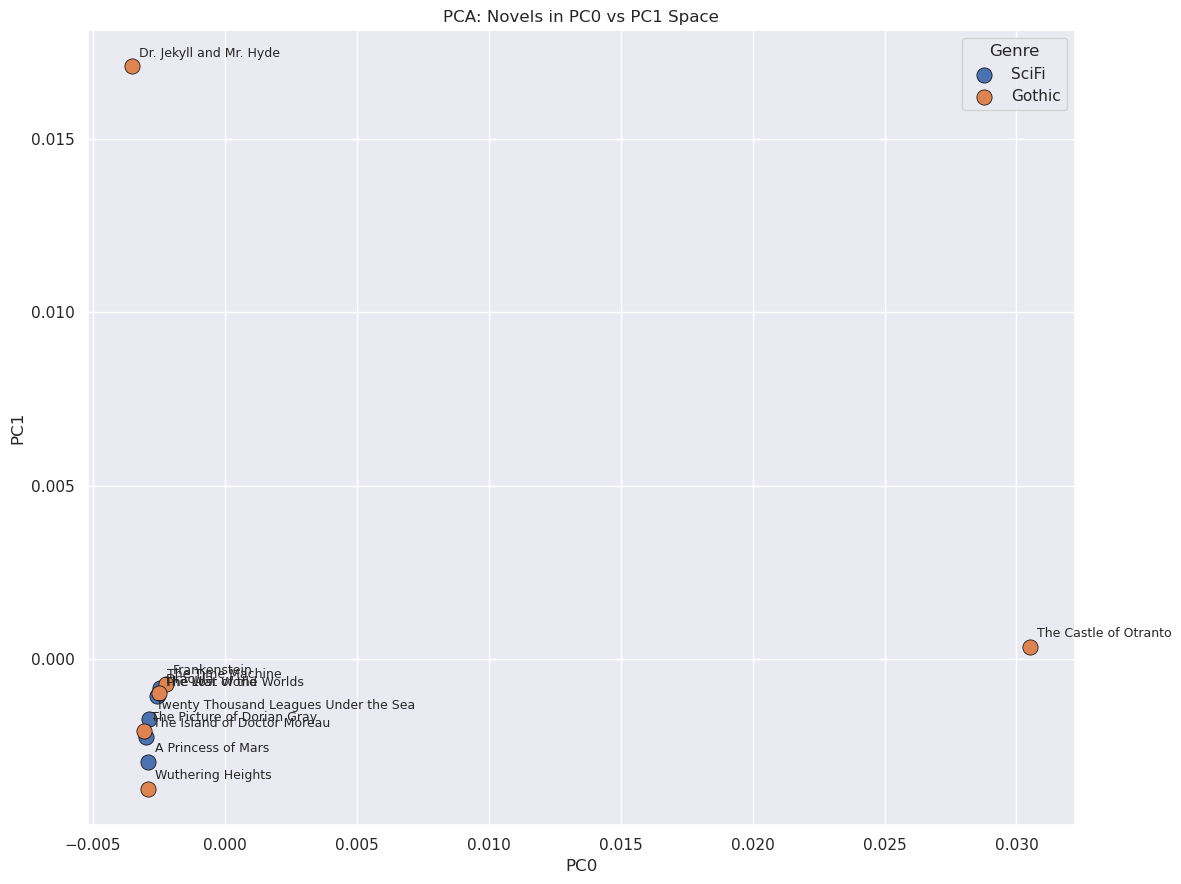

In [39]:
fig, ax = plt.subplots(figsize=(12, 9))
for genre in DOC_COMPONENTS['genre'].unique():
    subset = DOC_COMPONENTS[DOC_COMPONENTS['genre'] == genre]
    ax.scatter(subset['PC0'], subset['PC1'], label=genre, s=120, edgecolors='black', linewidth=0.5)
    for idx, row in subset.iterrows():
        ax.annotate(row['title'], (row['PC0'], row['PC1']),
                    fontsize=9, ha='left', va='bottom',
                    xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('PC0')
ax.set_ylabel('PC1')
ax.legend(title='Genre')
ax.set_title('PCA: Novels in PC0 vs PC1 Space')
plt.tight_layout()
plt.show()

# 5. KDE Plot: Sentiment Polarity by Genre

Distribution of per-chapter polarity for Gothic vs SciFi.

In [40]:
# Compute chapter-level polarity
chap_polarity = TOKEN.groupby(['book_id', 'chapter'])['polarity'].mean().reset_index()
chap_polarity['genre'] = chap_polarity['book_id'].map(id_to_genre)

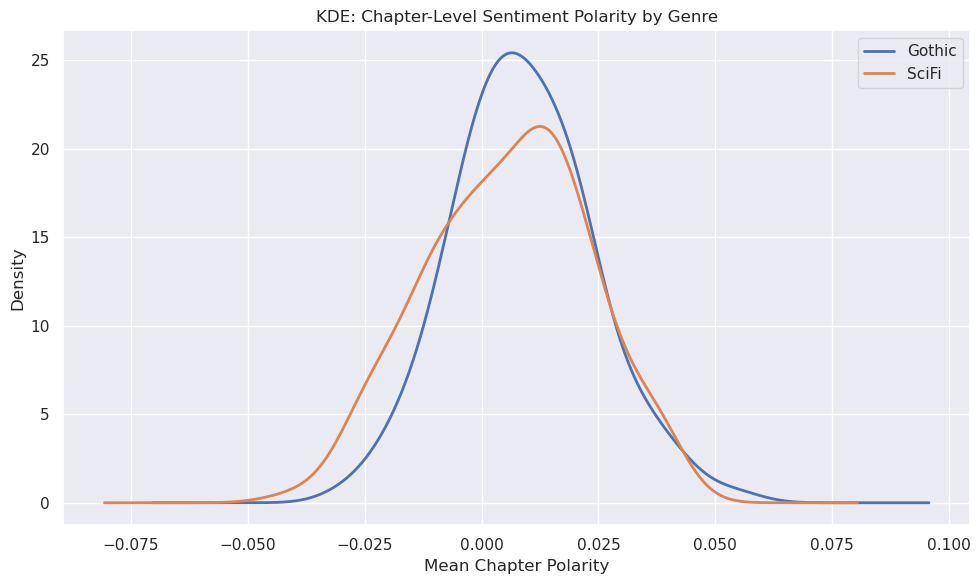

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
for genre in ['Gothic', 'SciFi']:
    subset = chap_polarity[chap_polarity['genre'] == genre]
    subset['polarity'].plot.kde(ax=ax, label=genre, linewidth=2)
ax.set_xlabel('Mean Chapter Polarity')
ax.set_title('KDE: Chapter-Level Sentiment Polarity by Genre')
ax.legend()
plt.tight_layout()
plt.show()

# 6. KDE Plot: Fear Emotion by Genre

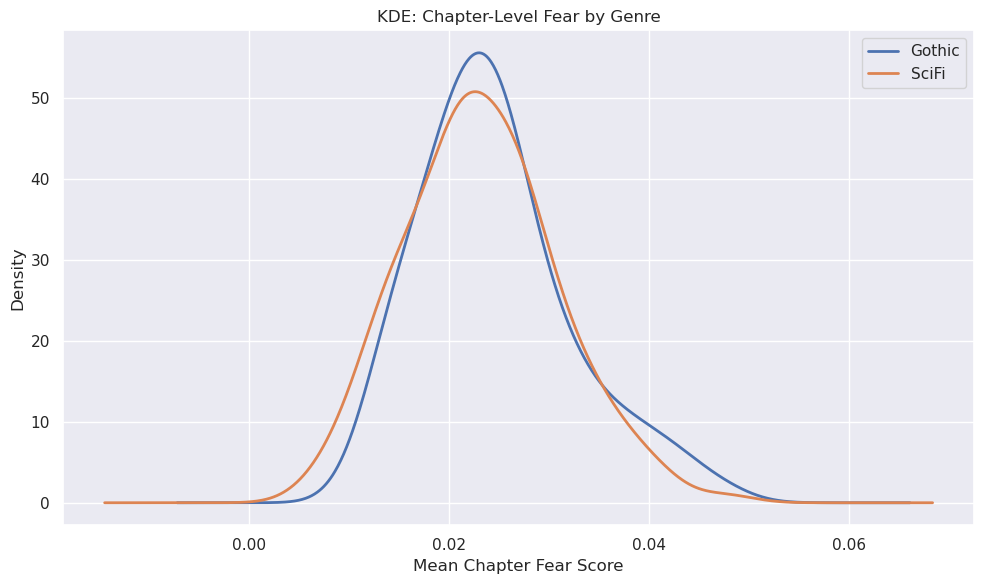

In [42]:
chap_fear = TOKEN.groupby(['book_id', 'chapter'])['fear'].mean().reset_index()
chap_fear['genre'] = chap_fear['book_id'].map(id_to_genre)

fig, ax = plt.subplots(figsize=(10, 6))
for genre in ['Gothic', 'SciFi']:
    subset = chap_fear[chap_fear['genre'] == genre]
    subset['fear'].plot.kde(ax=ax, label=genre, linewidth=2)
ax.set_xlabel('Mean Chapter Fear Score')
ax.set_title('KDE: Chapter-Level Fear by Genre')
ax.legend()
plt.tight_layout()
plt.show()

# 7. t-SNE Plot: Word Embeddings

Visualize word2vec embeddings in 2D using t-SNE. Focus on the top 500 most frequent non-stopword terms.

In [43]:
from sklearn.manifold import TSNE

In [44]:
# Get top 500 non-stopword terms that are in word2vec
vocab_nonstop = VOCAB[(VOCAB['stop'] == 0) & (VOCAB.index.isin(WORD2VEC.index))]
top_terms = vocab_nonstop.sort_values('n', ascending=False).head(500).index.tolist()

w2v_subset = WORD2VEC.loc[top_terms]
print(f't-SNE on {len(w2v_subset)} terms')

t-SNE on 500 terms


In [45]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(w2v_subset.values)

tsne_df = pd.DataFrame(tsne_result, index=w2v_subset.index, columns=['x', 'y'])

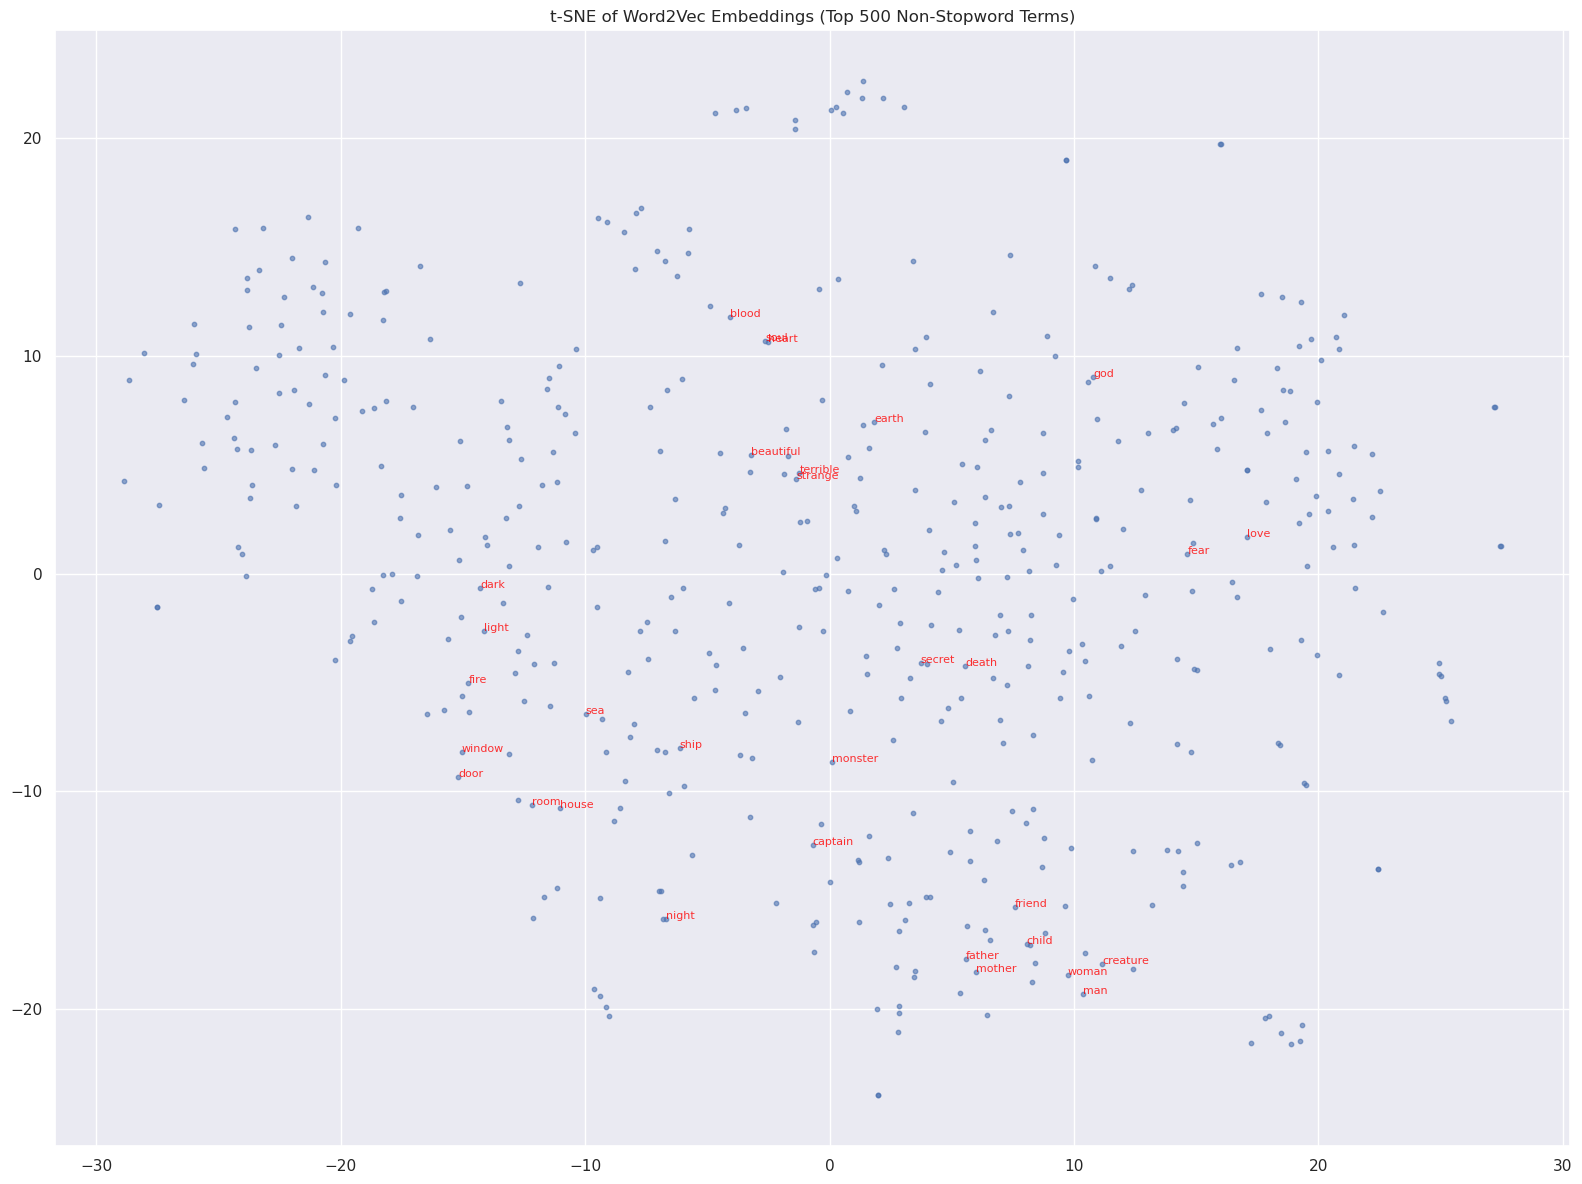

In [46]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.scatter(tsne_df['x'], tsne_df['y'], s=10, alpha=0.6)

# Label a subset of interesting terms
label_terms = [
    'death', 'love', 'fear', 'blood', 'monster', 'creature', 'science',
    'night', 'dark', 'light', 'heart', 'soul', 'god', 'evil', 'fire',
    'castle', 'sea', 'ship', 'captain', 'war', 'earth', 'moon',
    'woman', 'man', 'father', 'mother', 'child', 'friend', 'enemy',
    'door', 'house', 'room', 'window', 'garden', 'forest',
    'strange', 'terrible', 'beautiful', 'ancient', 'secret',
]
for term in label_terms:
    if term in tsne_df.index:
        ax.annotate(term, (tsne_df.loc[term, 'x'], tsne_df.loc[term, 'y']),
                    fontsize=8, alpha=0.8, color='red')

ax.set_title('t-SNE of Word2Vec Embeddings (Top 500 Non-Stopword Terms)')
plt.tight_layout()
plt.show()

# 8. Dispersion Plot: Key Terms Across Chapters

Show where key thematic terms appear across the chapters of selected novels.

In [47]:
def dispersion_plot(book_id, terms, title=None):
    """Plot term occurrences across chapters for a given book."""
    book_tokens = TOKEN[TOKEN['book_id'] == book_id].copy()
    book_tokens['position'] = range(len(book_tokens))
    
    fig, ax = plt.subplots(figsize=(16, 4))
    for i, term in enumerate(terms):
        positions = book_tokens[book_tokens['term_str'] == term]['position']
        ax.scatter(positions, [i] * len(positions), marker='|', s=30, label=term)
    
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xlabel('Token Position')
    ax.set_title(title or f'Dispersion Plot — {id_to_title[book_id]}')
    plt.tight_layout()
    plt.show()

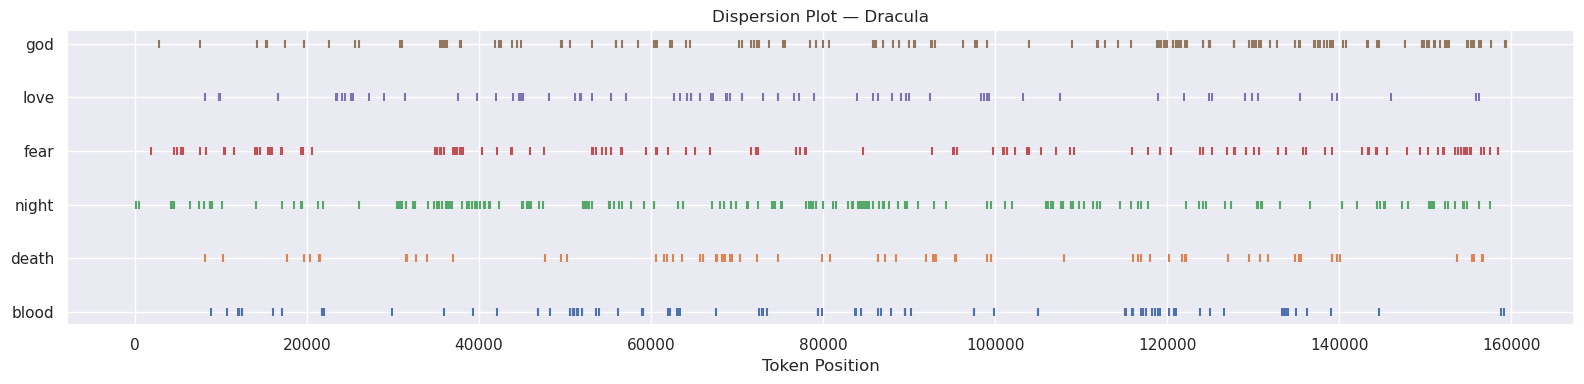

In [48]:
# Dracula: key character and theme terms
dispersion_plot(345, ['blood', 'death', 'night', 'fear', 'love', 'god'])

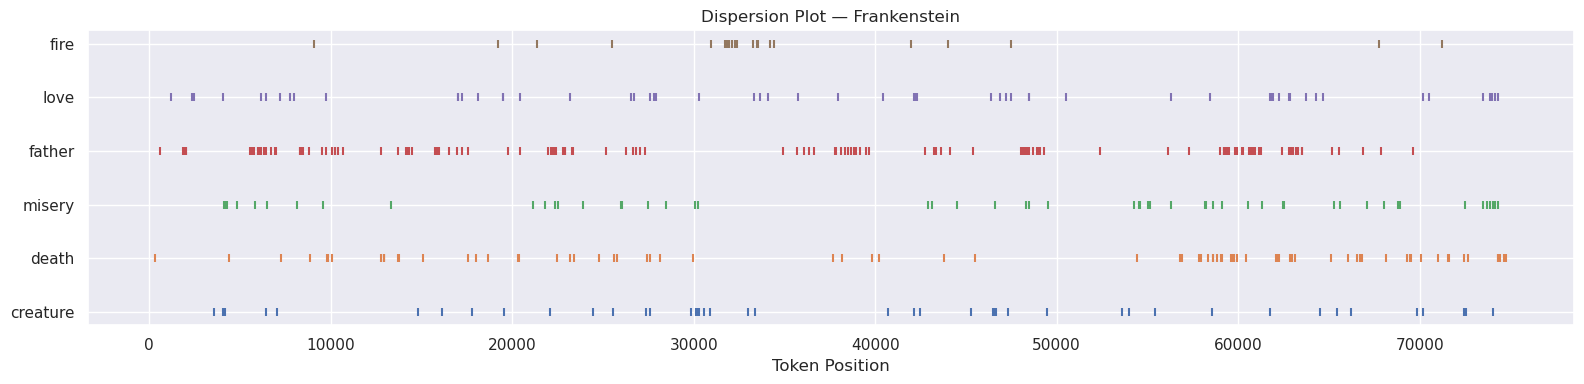

In [49]:
# Frankenstein
dispersion_plot(84, ['creature', 'death', 'misery', 'father', 'love', 'fire'])

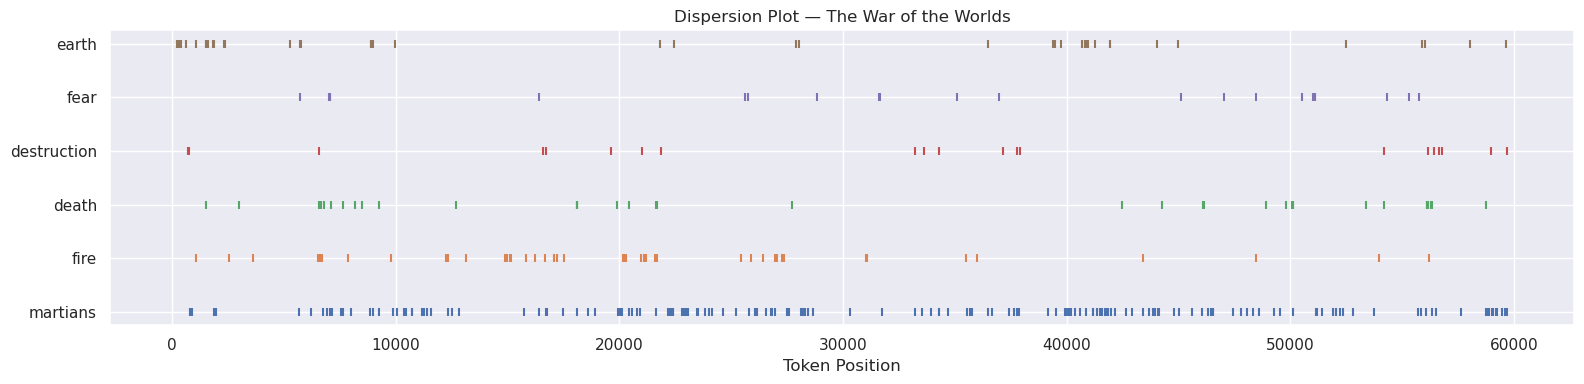

In [50]:
# War of the Worlds
dispersion_plot(36, ['martians', 'fire', 'death', 'destruction', 'fear', 'earth'])

# 9. Scatter Plot: Fear vs Trust by Novel

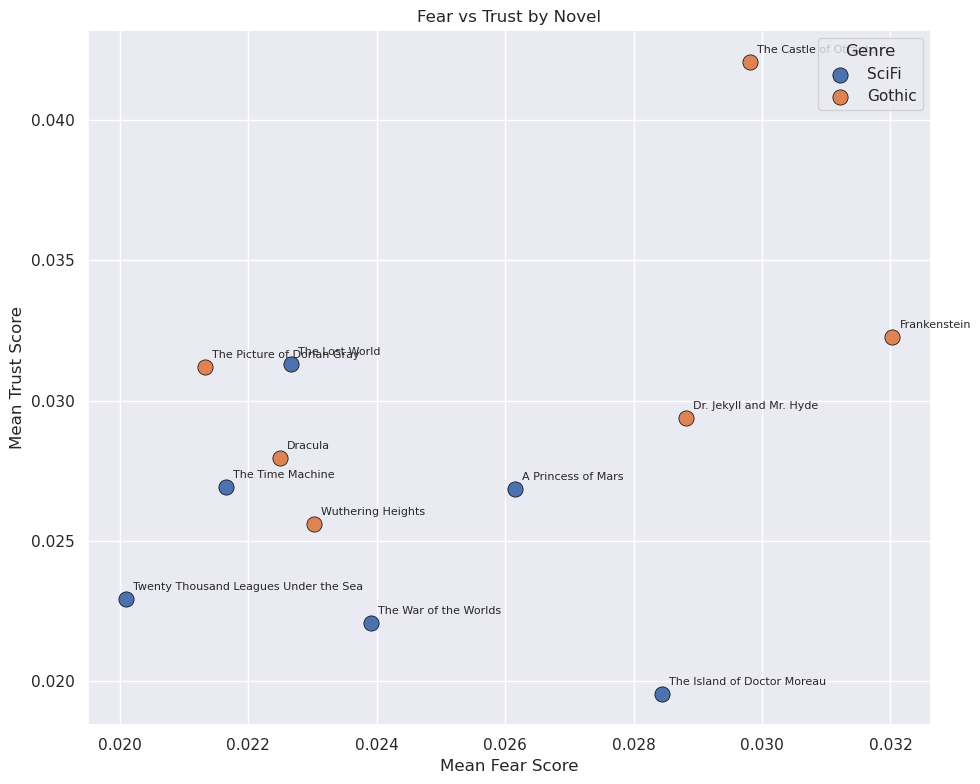

In [51]:
book_emo_idx = TOKEN.groupby('book_id')[emo_cols + ['polarity']].mean()
book_emo_idx = book_emo_idx.join(LIBRARY[['title', 'genre']])

fig, ax = plt.subplots(figsize=(10, 8))
for genre in book_emo_idx['genre'].unique():
    subset = book_emo_idx[book_emo_idx['genre'] == genre]
    ax.scatter(subset['fear'], subset['trust'], label=genre, s=120, edgecolors='black', linewidth=0.5)
    for idx, row in subset.iterrows():
        ax.annotate(row['title'], (row['fear'], row['trust']),
                    fontsize=8, ha='left', va='bottom',
                    xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Mean Fear Score')
ax.set_ylabel('Mean Trust Score')
ax.legend(title='Genre')
ax.set_title('Fear vs Trust by Novel')
plt.tight_layout()
plt.show()

# 10. Sentiment Arc: Polarity Over Chapters

In [52]:
def plot_sentiment_arc(book_id):
    title = id_to_title[book_id]
    chap = TOKEN[TOKEN['book_id'] == book_id].groupby('chapter')['polarity'].mean()
    chap.plot(figsize=(15, 4), title=f'{title} — Polarity Arc', linewidth=2)
    plt.xlabel('Chapter')
    plt.ylabel('Mean Polarity')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

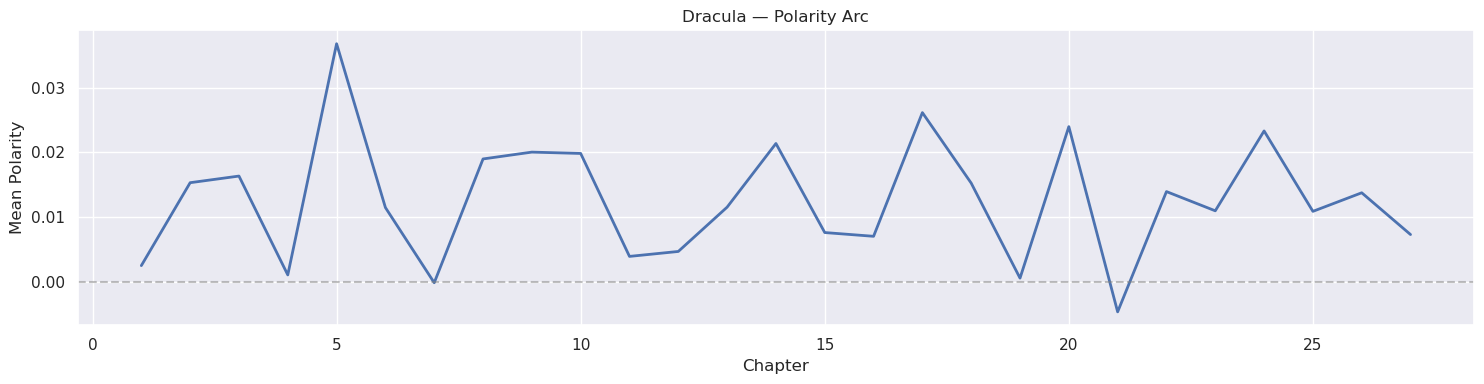

In [53]:
plot_sentiment_arc(345)  # Dracula

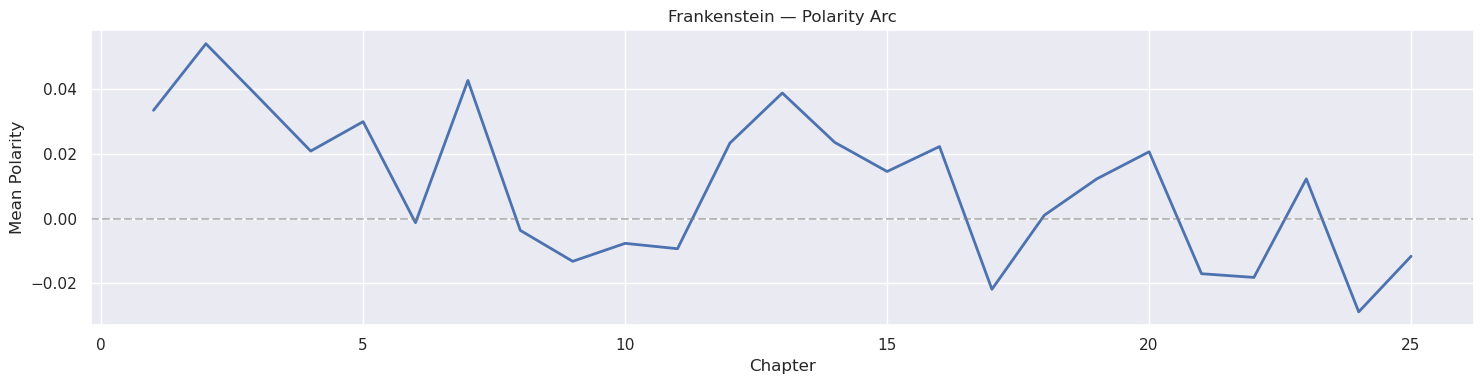

In [54]:
plot_sentiment_arc(84)   # Frankenstein

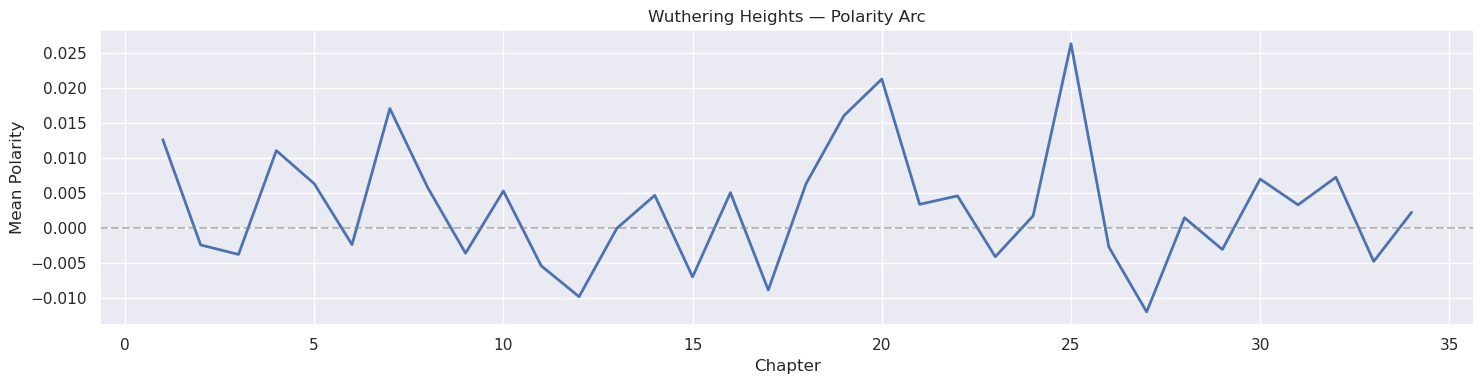

In [55]:
plot_sentiment_arc(768)  # Wuthering Heights

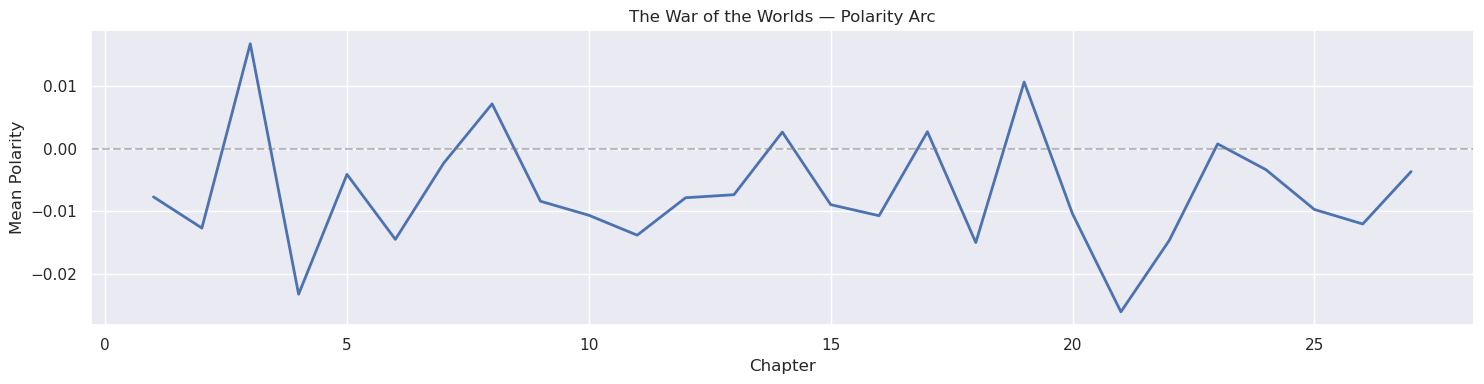

In [56]:
plot_sentiment_arc(36)   # War of the Worlds

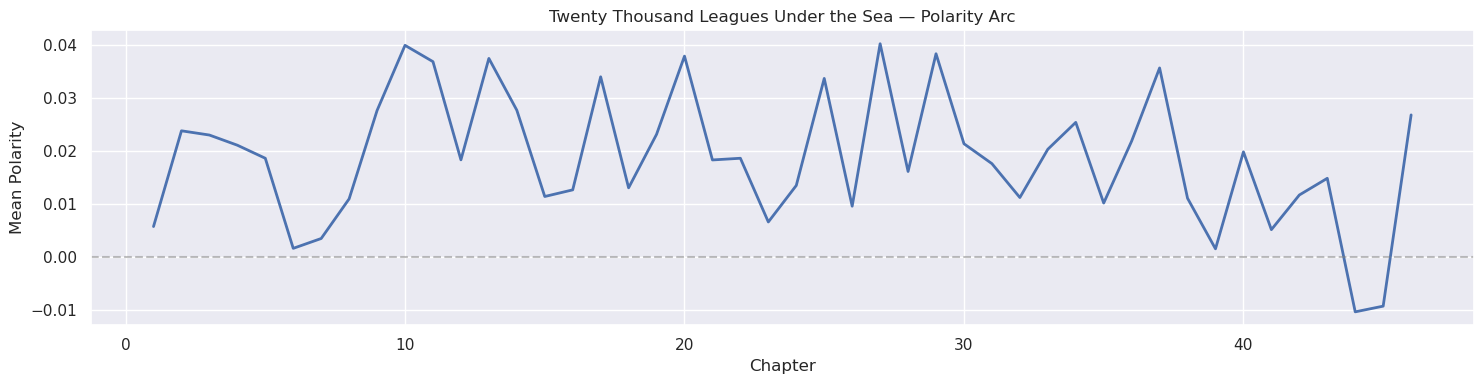

In [57]:
plot_sentiment_arc(164)  # Twenty Thousand Leagues

# 11. LDA Topic Heatmap by Genre

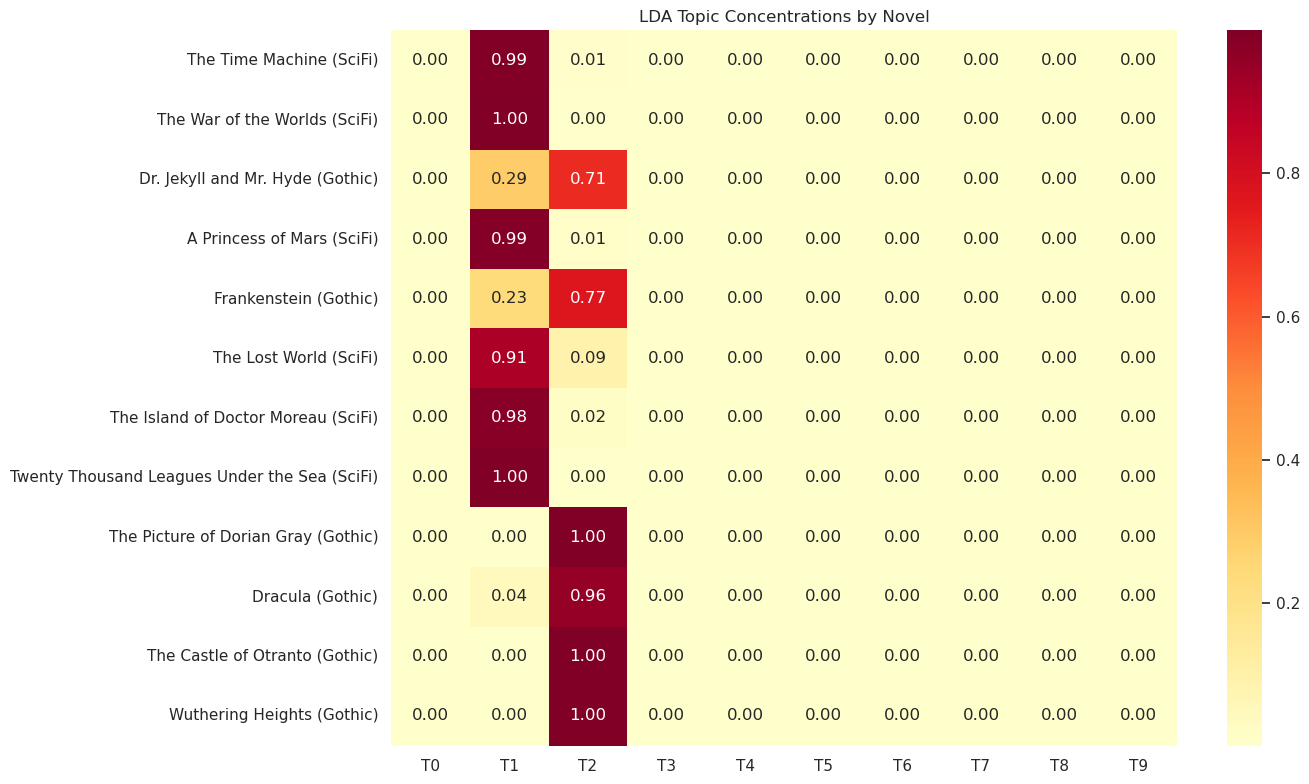

In [58]:
topic_cols = [c for c in DOC_TOPICS.columns if c.startswith('T')]

heatmap_data = DOC_TOPICS[topic_cols].copy()
heatmap_data.index = [f"{id_to_title[i]} ({id_to_genre[i]})" for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('LDA Topic Concentrations by Novel')
plt.tight_layout()
plt.show()

# Summary

Visualizations produced:
1. Hierarchical cluster dendrogram (TFIDF, cosine distance)
2. Heatmap: NRC emotion scores by novel
3. Heatmap: correlation of emotion profiles between novels
4. PCA scatter plot (PC0 vs PC1, colored by genre)
5. KDE: chapter-level polarity by genre
6. KDE: chapter-level fear by genre
7. t-SNE of word2vec embeddings
8. Dispersion plots for Dracula, Frankenstein, War of the Worlds
9. Scatter plot: fear vs trust by novel
10. Sentiment arcs for 5 novels
11. LDA topic heatmap

These cover all required visualization types: hierarchical clustering, heatmaps, scatter plots, KDE plots, dispersion plots, and t-SNE plots.

# Appendix: Numerical Results for Final Report

In [59]:
print('='*80)
print('CORPUS OVERVIEW')
print('='*80)
print(f'Number of books: {len(LIBRARY)}')
print(f'Total tokens: {len(TOKEN):,}')
print(f'Unique terms (vocab size): {len(VOCAB):,}')
print()
print('--- Books in corpus ---')
for bid in LIBRARY.index:
    row = LIBRARY.loc[bid]
    ntok = len(TOKEN[TOKEN['book_id'] == bid])
    print(f"  {bid}: {row['title']} by {row['author']} [{row['genre']}] — {ntok:,} tokens")

print()
print('--- Tokens per genre ---')
tok_genre = TOKEN.merge(LIBRARY[['genre']].reset_index(), on='book_id').groupby('genre').size()
print(tok_genre.to_string())

print()
print('='*80)
print('SENTIMENT ANALYSIS (NRC Emotion Lexicon)')
print('='*80)
print()
print('--- Mean emotion scores by book ---')
book_emo_full = TOKEN.groupby('book_id')[emo_cols + ['polarity']].mean()
book_emo_full = book_emo_full.join(LIBRARY[['title', 'genre']])
for bid in book_emo_full.index:
    row = book_emo_full.loc[bid]
    print(f"\n  {row['title']} ({row['genre']}):")
    for col in emo_cols + ['polarity']:
        print(f"    {col}: {row[col]:.4f}")

print()
print('--- Mean emotion scores by genre ---')
genre_emo = TOKEN.merge(LIBRARY[['genre']].reset_index(), on='book_id').groupby('genre')[emo_cols + ['polarity']].mean()
print(genre_emo.to_string())

print()
print('='*80)
print('PCA RESULTS')
print('='*80)
print()
print('--- Explained variance ratio ---')
pca_var = pd.read_csv(os.path.join(output_dir, 'DOC_COMPONENTS.csv'), index_col='book_id')
# Recompute from TFIDF
from sklearn.decomposition import PCA as PCA_cls
pca_refit = PCA_cls(n_components=10)
pca_refit.fit(TFIDF.values)
for i, v in enumerate(pca_refit.explained_variance_ratio_):
    print(f'  PC{i}: {v:.4f}')
print(f'  Cumulative: {sum(pca_refit.explained_variance_ratio_):.4f}')

print()
print('--- Top 5 positive loadings per PC (first 3 PCs) ---')
LOADINGS = pd.read_csv(os.path.join(output_dir, 'LOADINGS.csv'), index_col='term_str')
for pc in ['PC0', 'PC1', 'PC2']:
    print(f'\n  {pc} top positive:')
    top = LOADINGS[pc].sort_values(ascending=False).head(5)
    for t, v in top.items():
        print(f'    {t}: {v:.6f}')
    print(f'  {pc} top negative:')
    bot = LOADINGS[pc].sort_values().head(5)
    for t, v in bot.items():
        print(f'    {t}: {v:.6f}')

print()
print('='*80)
print('LDA TOPIC MODEL')
print('='*80)
print()
print('--- Top 8 terms per topic ---')
for topic in TOPIC_TERMS.index:
    top = TOPIC_TERMS.loc[topic].sort_values(ascending=False).head(8)
    terms = ', '.join([f'{t}({v:.4f})' for t, v in top.items()])
    print(f'  {topic}: {terms}')

print()
print('--- Dominant topic per book ---')
topic_cols_list = [c for c in DOC_TOPICS.columns if c.startswith('T')]
for bid in DOC_TOPICS.index:
    row = DOC_TOPICS.loc[bid]
    dominant = row[topic_cols_list].idxmax()
    val = row[dominant]
    title = row['title']
    print(f"  {title}: {dominant} ({val:.3f})")

print()
print('='*80)
print('TFIDF — TOP 5 DISTINCTIVE TERMS PER BOOK')
print('='*80)
for bid in LIBRARY.index:
    title = LIBRARY.loc[bid, 'title']
    top = TFIDF.loc[bid].sort_values(ascending=False).head(5)
    terms = ', '.join([f'{t}({v:.4f})' for t, v in top.items()])
    print(f'  {title}: {terms}')

print()
print('='*80)
print('WORD2VEC — SIMILAR WORDS')
print('='*80)
from gensim.models import Word2Vec as W2V_cls
# Rebuild sentences for w2v
sents_for_w2v = TOKEN.groupby(['book_id','chapter','para_num','sent_num'])['term_str'].apply(list).tolist()
w2v_model = W2V_cls(sents_for_w2v, vector_size=50, window=5, min_count=5, workers=1, seed=42, epochs=20)
for word in ['death', 'monster', 'science', 'love', 'fear', 'night', 'blood', 'woman']:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=5)
        sim_str = ', '.join([f'{w}({s:.3f})' for w, s in sims])
        print(f'  {word}: {sim_str}')

print()
print('='*80)
print('GENRE COMPARISON SUMMARY')
print('='*80)
print()
print('--- Gothic vs SciFi: mean polarity ---')
print(genre_emo[['polarity']].to_string())
print()
print('--- Gothic vs SciFi: mean fear ---')
print(genre_emo[['fear']].to_string())
print()
print('--- Gothic vs SciFi: mean trust ---')
print(genre_emo[['trust']].to_string())
print()
print('--- Gothic vs SciFi: mean joy ---')
print(genre_emo[['joy']].to_string())
print()
print('DONE — All numerical results printed.')

# ---- SAVE ALL REPORT FIGURES TO figures/ ----
import os
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

# Fig 1: Hierarchical Cluster Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
dist = pdist(TFIDF.values, metric='cosine')
Z = linkage(dist, method='ward')
labels = [id_to_title[i] for i in TFIDF.index]
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, labels=labels, leaf_rotation=45, leaf_font_size=11, ax=ax)
ax.set_title('Hierarchical Clustering of Novels (TFIDF, Cosine Distance, Ward Linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig1_dendrogram.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig1_dendrogram.png')

# Fig 2: Heatmap — NRC Emotion Scores by Novel
book_emo = TOKEN.groupby('book_id')[emo_cols].mean()
book_emo.index = [id_to_title[i] for i in book_emo.index]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(book_emo, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax)
ax.set_title('NRC Emotion Scores by Novel')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig2_emotion_heatmap.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig2_emotion_heatmap.png')

# Fig 3: PCA Scatter — PC0 vs PC1 by Genre
fig, ax = plt.subplots(figsize=(12, 9))
for genre in DOC_COMPONENTS['genre'].unique():
    subset = DOC_COMPONENTS[DOC_COMPONENTS['genre'] == genre]
    ax.scatter(subset['PC0'], subset['PC1'], label=genre, s=120, edgecolors='black', linewidth=0.5)
    for idx, row in subset.iterrows():
        ax.annotate(row['title'], (row['PC0'], row['PC1']),
                    fontsize=9, ha='left', va='bottom',
                    xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('PC0')
ax.set_ylabel('PC1')
ax.legend(title='Genre')
ax.set_title('PCA: Novels in PC0 vs PC1 Space')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig3_pca_scatter.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig3_pca_scatter.png')

# Fig 4: KDE — Chapter-Level Polarity by Genre
chap_pol = TOKEN.groupby(['book_id', 'chapter'])['polarity'].mean().reset_index()
chap_pol['genre'] = chap_pol['book_id'].map(id_to_genre)
fig, ax = plt.subplots(figsize=(10, 6))
for genre in ['Gothic', 'SciFi']:
    subset = chap_pol[chap_pol['genre'] == genre]
    subset['polarity'].plot.kde(ax=ax, label=genre, linewidth=2)
ax.set_xlabel('Mean Chapter Polarity')
ax.set_title('KDE: Chapter-Level Sentiment Polarity by Genre')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig4_kde_polarity.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig4_kde_polarity.png')

# Fig 5: t-SNE of Word2Vec Embeddings
from sklearn.manifold import TSNE
vocab_nonstop = VOCAB[(VOCAB['stop'] == 0) & (VOCAB.index.isin(WORD2VEC.index))]
top_terms = vocab_nonstop.sort_values('n', ascending=False).head(500).index.tolist()
w2v_subset = WORD2VEC.loc[top_terms]
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(w2v_subset.values)
tsne_df = pd.DataFrame(tsne_result, index=w2v_subset.index, columns=['x', 'y'])
fig, ax = plt.subplots(figsize=(16, 12))
ax.scatter(tsne_df['x'], tsne_df['y'], s=10, alpha=0.6)
label_terms = [
    'death', 'love', 'fear', 'blood', 'monster', 'creature', 'science',
    'night', 'dark', 'light', 'heart', 'soul', 'god', 'evil', 'fire',
    'castle', 'sea', 'ship', 'captain', 'war', 'earth', 'moon',
    'woman', 'man', 'father', 'mother', 'child', 'friend', 'enemy',
    'door', 'house', 'room', 'window', 'garden', 'forest',
    'strange', 'terrible', 'beautiful', 'ancient', 'secret',
]
for term in label_terms:
    if term in tsne_df.index:
        ax.annotate(term, (tsne_df.loc[term, 'x'], tsne_df.loc[term, 'y']),
                    fontsize=8, alpha=0.8, color='red')
ax.set_title('t-SNE of Word2Vec Embeddings (Top 500 Non-Stopword Terms)')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig5_tsne_embeddings.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig5_tsne_embeddings.png')

# Fig 6: LDA Topic Heatmap
topic_cols_list2 = [c for c in DOC_TOPICS.columns if c.startswith('T')]
heatmap_data = DOC_TOPICS[topic_cols_list2].copy()
heatmap_data.index = [f'{id_to_title[i]} ({id_to_genre[i]})' for i in heatmap_data.index]
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('LDA Topic Concentrations by Novel')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig6_lda_heatmap.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig6_lda_heatmap.png')

# Fig 7: Fear vs Trust Scatter
book_emo_idx = TOKEN.groupby('book_id')[emo_cols + ['polarity']].mean()
book_emo_idx = book_emo_idx.join(LIBRARY[['title', 'genre']])
fig, ax = plt.subplots(figsize=(10, 8))
for genre in book_emo_idx['genre'].unique():
    subset = book_emo_idx[book_emo_idx['genre'] == genre]
    ax.scatter(subset['fear'], subset['trust'], label=genre, s=120, edgecolors='black', linewidth=0.5)
    for idx, row in subset.iterrows():
        ax.annotate(row['title'], (row['fear'], row['trust']),
                    fontsize=8, ha='left', va='bottom',
                    xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Mean Fear Score')
ax.set_ylabel('Mean Trust Score')
ax.legend(title='Genre')
ax.set_title('Fear vs Trust by Novel')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig7_fear_vs_trust.png'), dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved fig7_fear_vs_trust.png')

# Fig 8: Sentiment Arc — Dracula
def save_sentiment_arc(book_id, filename):
    title = id_to_title[book_id]
    chap = TOKEN[TOKEN['book_id'] == book_id].groupby('chapter')['polarity'].mean()
    fig, ax = plt.subplots(figsize=(15, 4))
    chap.plot(ax=ax, linewidth=2)
    ax.set_title(f'{title} — Polarity Arc')
    ax.set_xlabel('Chapter')
    ax.set_ylabel('Mean Polarity')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, filename), dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {filename}')

save_sentiment_arc(345, 'fig8_arc_dracula.png')
save_sentiment_arc(84, 'fig9_arc_frankenstein.png')

# Fig 10: Dispersion Plot — Dracula
def save_dispersion_plot(book_id, terms, filename):
    book_tokens = TOKEN[TOKEN['book_id'] == book_id].copy()
    book_tokens['position'] = range(len(book_tokens))
    title = id_to_title[book_id]
    fig, ax = plt.subplots(figsize=(16, 4))
    for i, term in enumerate(terms):
        positions = book_tokens[book_tokens['term_str'] == term]['position']
        ax.scatter(positions, [i] * len(positions), marker='|', s=30, label=term)
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xlabel('Token Position')
    ax.set_title(f'Dispersion Plot — {title}')
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, filename), dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {filename}')

save_dispersion_plot(345, ['blood', 'death', 'night', 'fear', 'love', 'god'], 'fig10_dispersion_dracula.png')

print()
print('All report figures saved to figures/ directory.')

CORPUS OVERVIEW
Number of books: 12
Total tokens: 871,168
Unique terms (vocab size): 25,122

--- Books in corpus ---
  35: The Time Machine by Wells, H. G. [SciFi] — 32,459 tokens
  36: The War of the Worlds by Wells, H. G. [SciFi] — 60,064 tokens
  42: Dr. Jekyll and Mr. Hyde by Stevenson, Robert Louis [Gothic] — 25,465 tokens
  62: A Princess of Mars by Burroughs, Edgar Rice [SciFi] — 65,882 tokens
  84: Frankenstein by Shelley, Mary [Gothic] — 74,896 tokens
  139: The Lost World by Doyle, Arthur Conan [SciFi] — 75,017 tokens
  159: The Island of Doctor Moreau by Wells, H. G. [SciFi] — 43,034 tokens
  164: Twenty Thousand Leagues Under the Sea by Verne, Jules [SciFi] — 102,890 tokens
  174: The Picture of Dorian Gray by Wilde, Oscar [Gothic] — 79,056 tokens
  345: Dracula by Stoker, Bram [Gothic] — 159,926 tokens
  696: The Castle of Otranto by Walpole, Horace [Gothic] — 34,985 tokens
  768: Wuthering Heights by Brontë, Emily [Gothic] — 117,494 tokens

--- Tokens per genre ---
genre


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  death: youth(0.638), life(0.611), happiness(0.591), memory(0.590), passion(0.589)
  monster: creature(0.611), fiend(0.581), threat(0.575), picture(0.565), shock(0.554)
  science: natural(0.734), knowledge(0.727), scientific(0.685), society(0.673), species(0.673)
  love: loved(0.702), play(0.696), trust(0.665), pity(0.665), wrong(0.659)
  fear: hope(0.709), trouble(0.696), dread(0.663), danger(0.644), comfort(0.622)
  night: day(0.808), evening(0.756), morning(0.721), afternoon(0.676), sleep(0.584)
  blood: flesh(0.752), bosom(0.747), veins(0.677), lips(0.671), body(0.671)
  woman: girl(0.823), boy(0.751), child(0.749), lady(0.747), gentleman(0.732)

GENRE COMPARISON SUMMARY

--- Gothic vs SciFi: mean polarity ---
        polarity
genre           
Gothic  0.008759
SciFi   0.006129

--- Gothic vs SciFi: mean fear ---
            fear
genre           
Gothic  0.024737
SciFi   0.023343

--- Gothic vs SciFi: mean trust ---
           trust
genre           
Gothic  0.029661
SciFi   0.02509